#  Keyword Extraction
## Recruitment NLP Lab — Step 4: Extracting Important Keywords with TF-IDF

This notebook extracts the most important keywords and phrases from resumes
and job descriptions using **TF-IDF (Term Frequency-Inverse Document Frequency)**.

**What TF-IDF does:**
- TF (Term Frequency): How often a word appears in a document
- IDF (Inverse Document Frequency): How rare the word is across all documents
- Words with high TF-IDF are important to that document but not common everywhere

**Goals:**
- Extract top keywords per resume category
- Extract top keywords per job title
- Visualize keywords as bar charts and word clouds
- Save TF-IDF vectors for use in the classification model (next notebook)

**Inputs:**
- `data/processed/resumes_cleaned.csv` -> 466 rows
- `data/processed/jobs_cleaned.csv`    -> 50,000 rows

##  1. Install & Import Libraries

In [1]:
!pip install scikit-learn wordcloud matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', 100)
os.makedirs("../results/plots", exist_ok=True)

print(" Libraries imported successfully!")

 Libraries imported successfully!


##  2. Load Cleaned Data

Loading preprocessed files saved from `02_preprocessing.ipynb`.

In [3]:
resumes = pd.read_csv("../data/processed/resumes_cleaned.csv")
jobs    = pd.read_csv("../data/processed/jobs_cleaned.csv")

print(f" Resumes loaded -> {resumes.shape[0]} rows, columns: {resumes.columns.tolist()}")
print(f" Jobs loaded    -> {jobs.shape[0]:,} rows, columns: {jobs.columns.tolist()}")

print(f"\nResume categories:\n{resumes['Category'].value_counts()}")

 Resumes loaded -> 466 rows, columns: ['ID', 'Category', 'cleaned_text']
 Jobs loaded    -> 50,000 rows, columns: ['Job Id', 'Job Title', 'Role', 'cleaned_text']

Resume categories:
Category
INFORMATION-TECHNOLOGY    120
ENGINEERING               118
ACCOUNTANT                118
HR                        110
Name: count, dtype: int64


##  3. TF-IDF on Resumes

Fitting TF-IDF across all resume documents to find the most important
keywords per category.

**Parameters used:**
- `max_features=5000` — keep top 5000 terms by frequency
- `ngram_range=(1,2)` — capture single words AND 2-word phrases (e.g., "machine learning")
- `min_df=2` — ignore terms that appear in fewer than 2 documents

In [4]:
# Fit TF-IDF on all resumes
resume_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

resume_tfidf_matrix = resume_tfidf.fit_transform(resumes['cleaned_text'])
resume_feature_names = resume_tfidf.get_feature_names_out()

print(f"  TF-IDF matrix shape: {resume_tfidf_matrix.shape}")
print(f"   (rows=resumes, cols=unique terms)")
print(f"\nSample features: {list(resume_feature_names[:20])}")

  TF-IDF matrix shape: (466, 5000)
   (rows=resumes, cols=unique terms)

Sample features: ['aa', 'ability', 'ability manage', 'ability multitask', 'ability work', 'able', 'abreast', 'absence', 'academic', 'academy', 'acceptance', 'accepted', 'access', 'access database', 'access excel', 'access microsoft', 'access outlook', 'access powerpoint', 'accessory', 'accident']


### 3.1 Top Keywords Per Resume Category

Computing the mean TF-IDF score per term for each category to find
the most representative keywords.

In [6]:
# Get top N keywords per category
def get_top_keywords(tfidf_matrix, labels, feature_names, category, top_n=15):
    """Returns top N keywords for a given category based on mean TF-IDF score."""
    
    # Get indices of documents in this category
    indices = [i for i, label in enumerate(labels) if label == category]
    
    # Mean TF-IDF score across documents in this category
    category_matrix = tfidf_matrix[indices]
    mean_scores = category_matrix.mean(axis=0).A1
    
    # Get top N indices
    top_indices = mean_scores.argsort()[-top_n:][::-1]
    top_keywords = [(feature_names[i], mean_scores[i]) for i in top_indices]
    
    return top_keywords

# Test for one category
categories = resumes['Category'].unique()
print(f"Categories: {categories}\n")

for cat in categories:
    keywords = get_top_keywords(
        resume_tfidf_matrix,
        resumes['Category'].tolist(),
        resume_feature_names,
        cat,
        top_n=20
    )
    print(f"\n  {cat}")
    for word, score in keywords:
        print(f"   {word:<30} {score:.4f}")

Categories: ['HR' 'INFORMATION-TECHNOLOGY' 'ENGINEERING' 'ACCOUNTANT']


  HR
   hr                             0.1639
   employee                       0.1499
   human resource                 0.0924
   human                          0.0920
   resource                       0.0778
   management                     0.0775
   benefit                        0.0742
   company                        0.0580
   recruitment                    0.0578
   state                          0.0556
   payroll                        0.0492
   training                       0.0489
   policy                         0.0486
   program                        0.0479
   city                           0.0466
   city state                     0.0454
   recruiting                     0.0442
   relation                       0.0426
   hire                           0.0414
   new                            0.0407

  INFORMATION-TECHNOLOGY
   network                        0.1007
   technology                     0

### 3.2 Visualize Top Keywords Per Resume Category

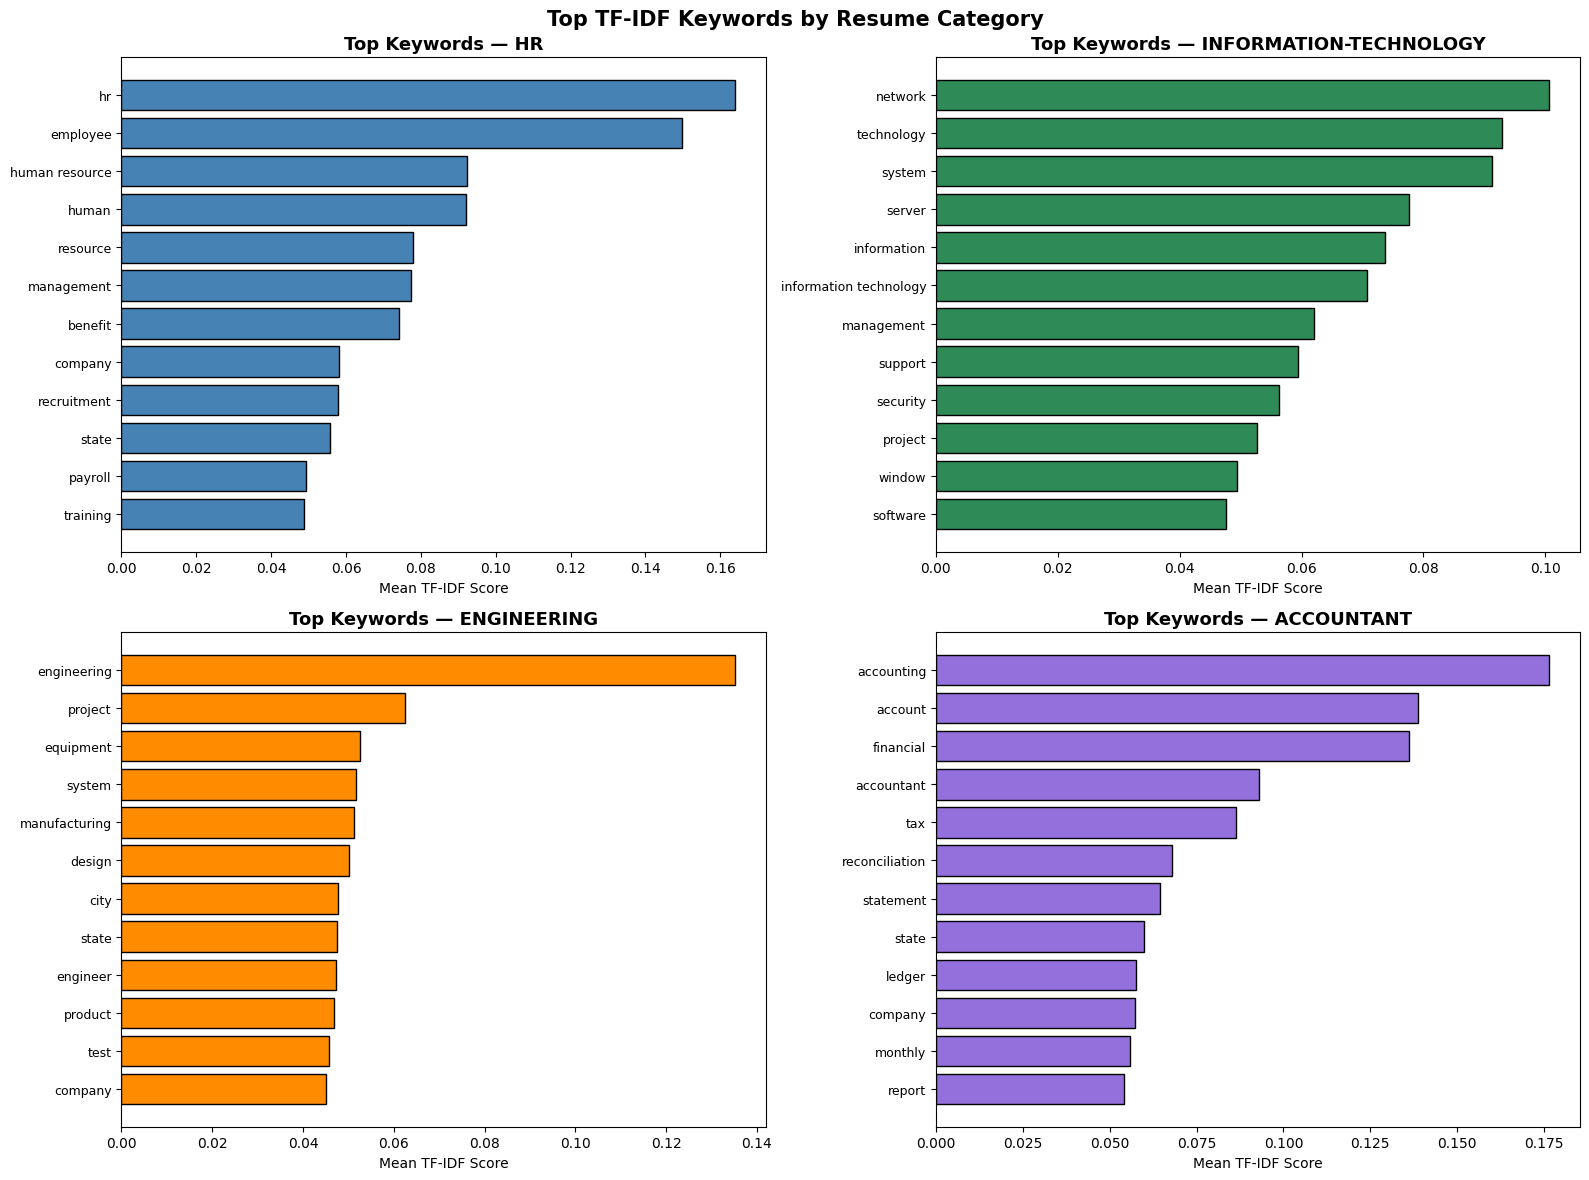

 Plot saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

for idx, cat in enumerate(categories):
    keywords = get_top_keywords(
        resume_tfidf_matrix,
        resumes['Category'].tolist(),
        resume_feature_names,
        cat,
        top_n=12
    )
    
    words  = [k[0] for k in keywords]
    scores = [k[1] for k in keywords]
    
    axes[idx].barh(words[::-1], scores[::-1], color=colors[idx], edgecolor='black')
    axes[idx].set_title(f'Top Keywords — {cat}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Mean TF-IDF Score')
    axes[idx].tick_params(axis='y', labelsize=9)

plt.suptitle('Top TF-IDF Keywords by Resume Category', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/plots/resume_keywords_per_category.png", dpi=150)
plt.show()
print(" Plot saved!")

### 3.3 Word Clouds Per Resume Category

Word clouds give a visual summary — larger words have higher TF-IDF scores.

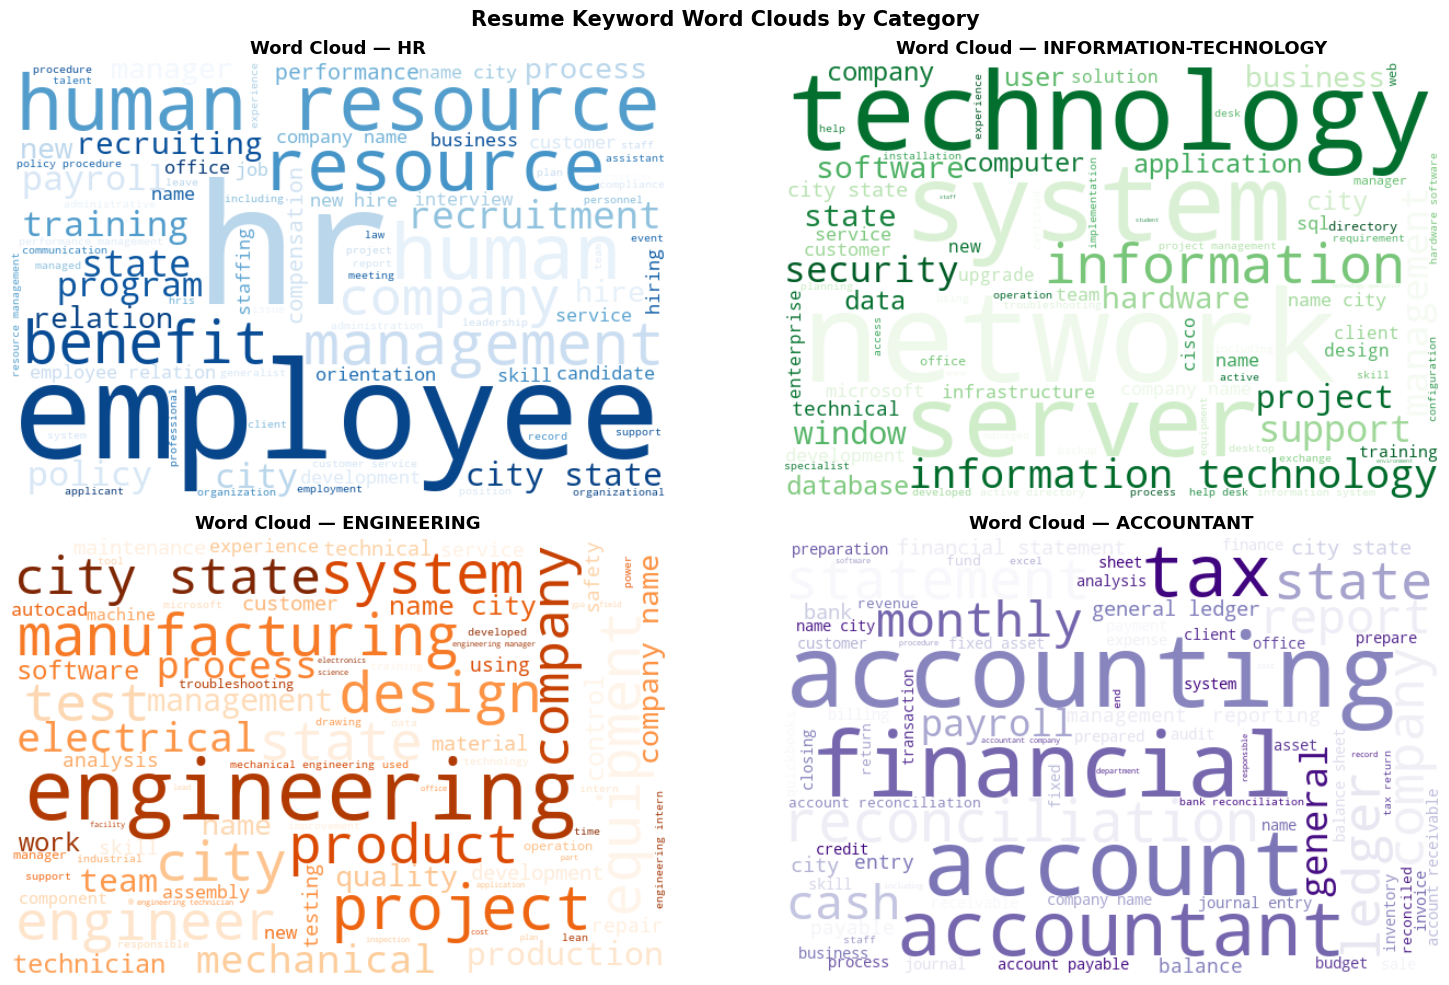

 Word clouds saved!


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colormap_list = ['Blues', 'Greens', 'Oranges', 'Purples']

for idx, cat in enumerate(categories):
    # Get all keywords with scores for this category
    indices = [i for i, label in enumerate(resumes['Category'].tolist()) if label == cat]
    category_matrix = resume_tfidf_matrix[indices]
    mean_scores = category_matrix.mean(axis=0).A1
    
    # Build word:score dict for wordcloud
    word_scores = {resume_feature_names[i]: mean_scores[i] 
                   for i in range(len(resume_feature_names)) if mean_scores[i] > 0}
    
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=colormap_list[idx],
        max_words=80
    ).generate_from_frequencies(word_scores)
    
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'Word Cloud — {cat}', fontsize=13, fontweight='bold')

plt.suptitle('Resume Keyword Word Clouds by Category', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/plots/resume_wordclouds.png", dpi=150)
plt.show()
print(" Word clouds saved!")

##  4. TF-IDF on Job Descriptions

Now fitting TF-IDF on the 50,000 sampled job descriptions.

In [9]:
job_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3
)

job_tfidf_matrix = job_tfidf.fit_transform(jobs['cleaned_text'])
job_feature_names = job_tfidf.get_feature_names_out()

print(f" Job TF-IDF matrix shape: {job_tfidf_matrix.shape}")
print(f"\nSample features: {list(job_feature_names[:20])}")

 Job TF-IDF matrix shape: (50000, 5000)

Sample features: ['ab', 'ab testing', 'ability', 'abuse', 'academic', 'academic journal', 'access', 'access control', 'access excel', 'accessibility', 'accessibility standard', 'accessible', 'account', 'account create', 'account ensure', 'account executive', 'account identify', 'account management', 'account manager', 'account negotiate']


### 4.1 Top Keywords Across All Job Titles

Instead of limiting to top titles, keywords across ALL unique
job titles in the sample are analysed, then the top 10 most frequent titles are visualized.

In [11]:
# Get all unique job titles and their counts
all_titles = jobs['Job Title'].value_counts()

print(f"Total unique job titles in sample: {len(all_titles)}")
print(f"\nTop 20 Job Titles:")
print(all_titles.head(20))

Total unique job titles in sample: 147

Top 20 Job Titles:
Job Title
UX/UI Designer                  1535
Digital Marketing Specialist     863
Software Engineer                854
Network Engineer                 775
Executive Assistant              736
Software Tester                  654
Financial Advisor                647
Procurement Manager              626
Systems Administrator            586
Network Administrator            565
Event Planner                    544
Administrative Assistant         531
Procurement Specialist           531
Purchasing Agent                 529
Social Media Manager             526
Customer Support Specialist      522
Sales Representative             518
HR Coordinator                   515
Data Analyst                     491
UI Developer                     465
Name: count, dtype: int64


In [12]:
# Get top keywords for ALL job titles and store results
all_title_keywords = {}

for title in all_titles.index:
    # Only process titles with at least 10 resumes for meaningful results
    if all_titles[title] >= 10:
        keywords = get_top_keywords(
            job_tfidf_matrix,
            jobs['Job Title'].tolist(),
            job_feature_names,
            title,
            top_n=10
        )
        all_title_keywords[title] = keywords

print(f"   Keywords extracted for {len(all_title_keywords)} job titles")
print(f"   (titles with fewer than 10 samples were skipped)")

# Preview keywords for a few titles
preview_titles = list(all_title_keywords.keys())[:4]
for title in preview_titles:
    print(f"\n  {title}")
    for word, score in all_title_keywords[title]:
        print(f"   {word:<35} {score:.4f}")

   Keywords extracted for 147 job titles
   (titles with fewer than 10 samples were skipped)

  UX/UI Designer
   user                                0.2949
   design                              0.1929
   interaction                         0.1928
   interface                           0.1364
   interaction design                  0.1092
   digital                             0.1078
   user experience                     0.0799
   digital interface                   0.0737
   experience                          0.0727
   user behavior                       0.0715

  Digital Marketing Specialist
   social                              0.2248
   social medium                       0.2113
   medium                              0.1946
   seo                                 0.1632
   content                             0.1390
   search                              0.0930
   email                               0.0875
   ranking                             0.0774
   metric                    

### 4.2 Visualize Top Keywords — Top 10 Job Titles by Frequency

Plotting the top 12 keywords for the 10 most frequent job titles in the sample.

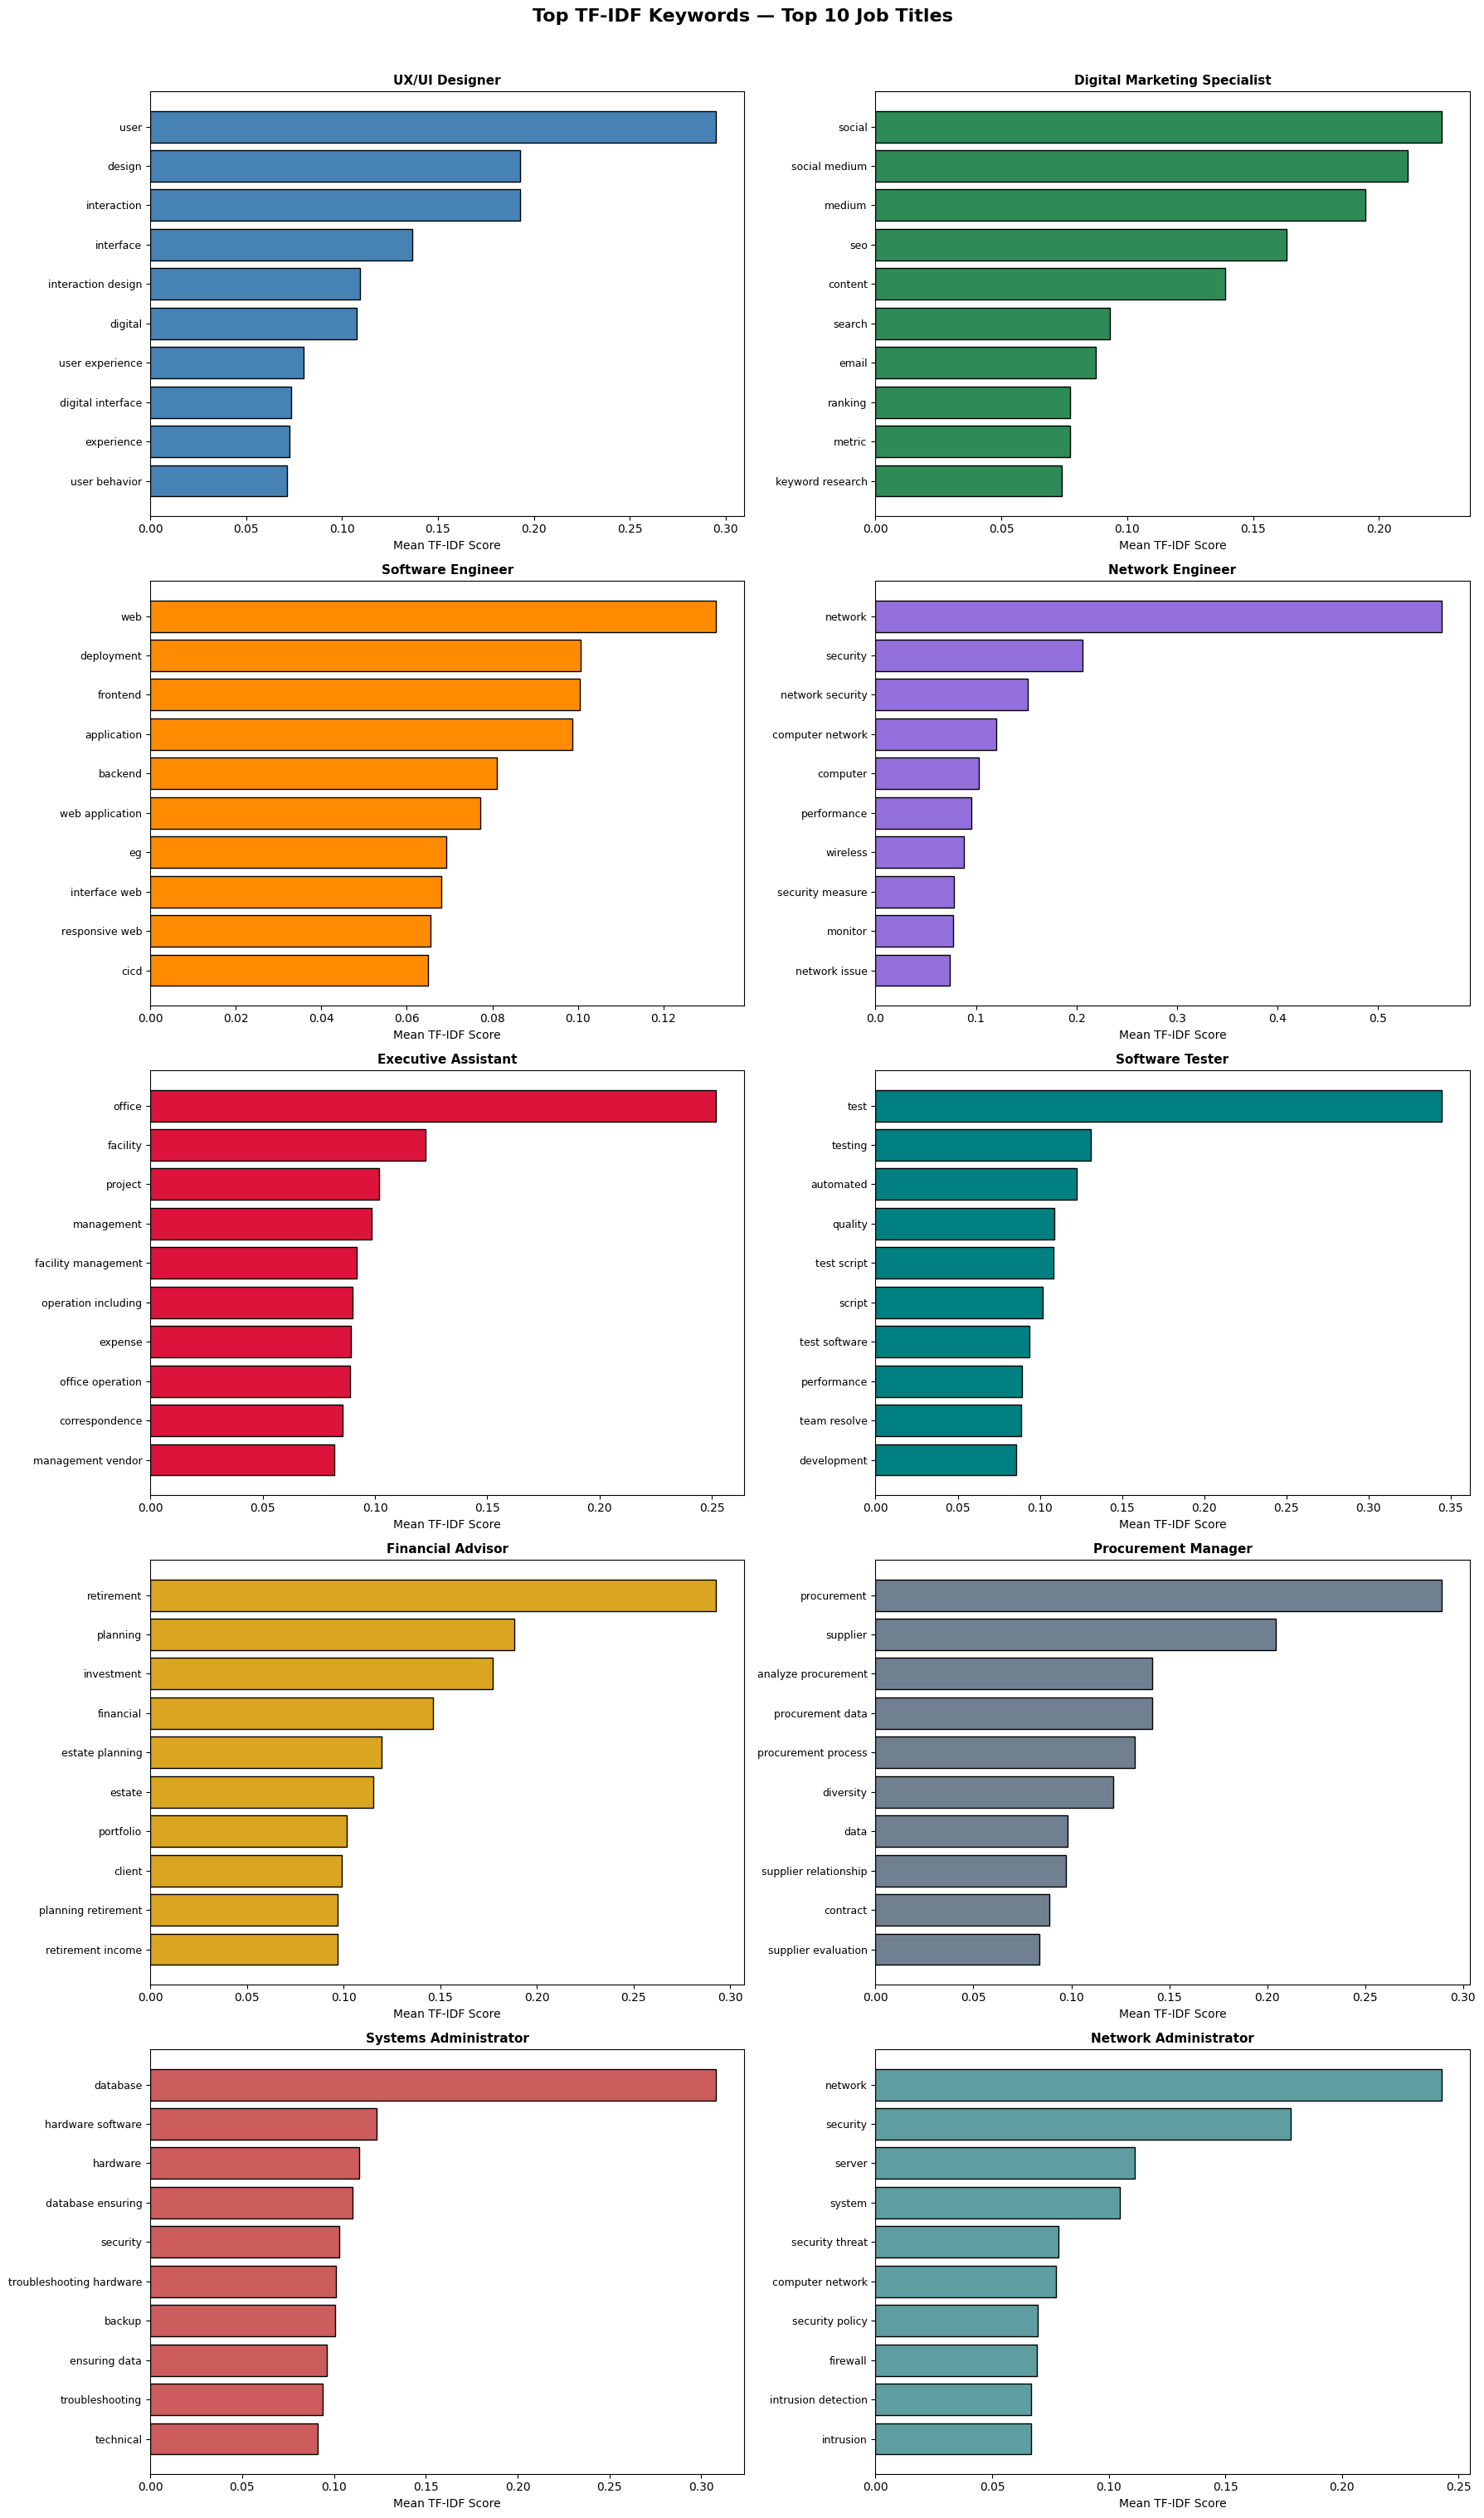

 Plot saved! Visualized keywords for 10 job titles


In [13]:
# Visualize top 12 keywords for top 10 most frequent job titles
top_10_titles = all_titles.head(10).index.tolist()

fig, axes = plt.subplots(5, 2, figsize=(18, 30))
axes = axes.flatten()

# Color palette cycling across 10 plots
colors = [
    'steelblue', 'seagreen', 'darkorange', 'mediumpurple', 'crimson',
    'teal', 'goldenrod', 'slategray', 'indianred', 'cadetblue'
]

for idx, title in enumerate(top_10_titles):
    if title not in all_title_keywords:
        continue

    keywords = all_title_keywords[title][:12]
    words  = [k[0] for k in keywords]
    scores = [k[1] for k in keywords]

    axes[idx].barh(words[::-1], scores[::-1], color=colors[idx], edgecolor='black')
    axes[idx].set_title(f'{title}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Mean TF-IDF Score')
    axes[idx].tick_params(axis='y', labelsize=9)

plt.suptitle('Top TF-IDF Keywords — Top 10 Job Titles', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("../results/plots/job_keywords_top10_titles.png", dpi=150, bbox_inches='tight')
plt.show()
print(f" Plot saved! Visualized keywords for {len(top_10_titles)} job titles")

### 4.3 Overall Word Cloud — All Job Descriptions Combined

Visualizing the most frequent keywords across all 50,000 job descriptions.

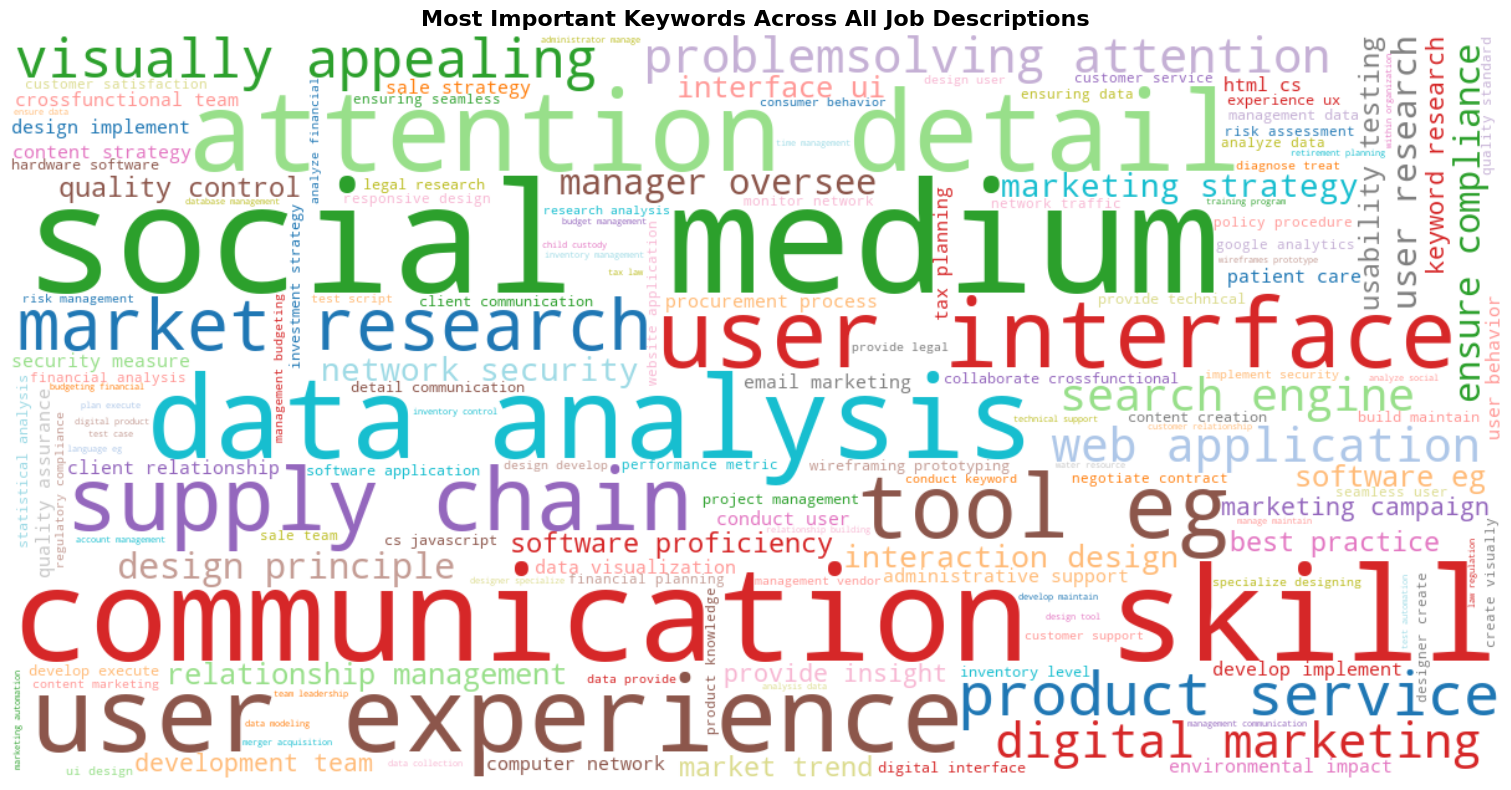

 Overall job word cloud saved!


In [14]:
# Overall word cloud across ALL job descriptions
all_job_text = ' '.join(jobs['cleaned_text'].tolist())

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='tab20',
    max_words=150
).generate(all_job_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Important Keywords Across All Job Descriptions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/plots/all_jobs_wordcloud.png", dpi=150)
plt.show()
print(" Overall job word cloud saved!")

##  5. Save TF-IDF Vectors for Next Notebook

Saving the fitted TF-IDF vectorizers and matrices so they can be
loaded directly in `04_classification.ipynb` without reprocessing.

In [16]:
import pickle

os.makedirs("../data/processed", exist_ok=True)

# Save fitted vectorizers
with open("../data/processed/resume_tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(resume_tfidf, f)

with open("../data/processed/job_tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(job_tfidf, f)

# Save TF-IDF matrices
import scipy.sparse as sp
sp.save_npz("../data/processed/resume_tfidf_matrix.npz", resume_tfidf_matrix)
sp.save_npz("../data/processed/job_tfidf_matrix.npz",    job_tfidf_matrix)

# Save labels
resumes[['ID', 'Category']].to_csv("../data/processed/resume_labels.csv", index=False)
jobs[['Job Id', 'Job Title', 'Role']].to_csv("../data/processed/job_labels.csv", index=False)

print(" Saved to data/processed/:")
print("   resume_tfidf_vectorizer.pkl")
print("   job_tfidf_vectorizer.pkl")
print("   resume_tfidf_matrix.npz")
print("   job_tfidf_matrix.npz")
print("   resume_labels.csv")
print("   job_labels.csv")

 Saved to data/processed/:
   resume_tfidf_vectorizer.pkl
   job_tfidf_vectorizer.pkl
   resume_tfidf_matrix.npz
   job_tfidf_matrix.npz
   resume_labels.csv
   job_labels.csv


##  6. Keyword Overlap Analysis — Resumes vs Job Descriptions

How many keywords appear in BOTH resumes and job descriptions?
This gives us a sense of how well resumes align with job market language.

Resume vocabulary size   : 5,000
Job vocabulary size      : 5,000
Overlapping keywords     : 1,325  (26.5% of resume vocab)
Resume-only keywords     : 3,675
Job-only keywords        : 3,675


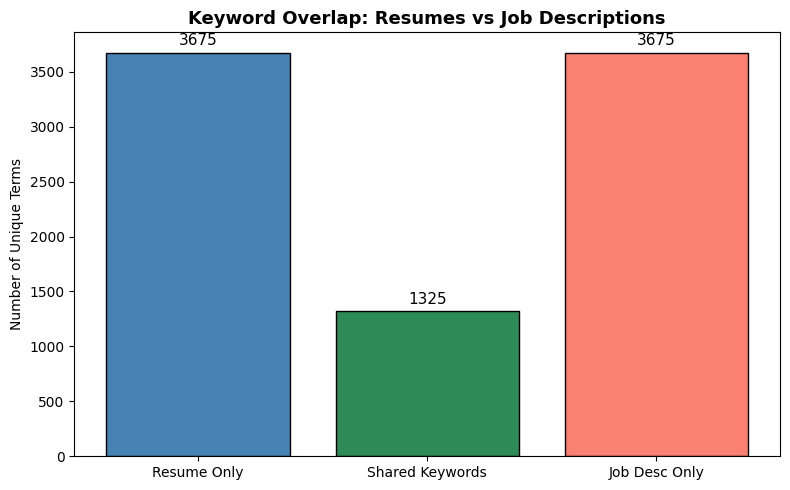

 Plot saved!


In [17]:
resume_vocab = set(resume_feature_names)
job_vocab    = set(job_feature_names)

overlap      = resume_vocab & job_vocab
resume_only  = resume_vocab - job_vocab
job_only     = job_vocab    - resume_vocab

print(f"Resume vocabulary size   : {len(resume_vocab):,}")
print(f"Job vocabulary size      : {len(job_vocab):,}")
print(f"Overlapping keywords     : {len(overlap):,}  ({len(overlap)/len(resume_vocab)*100:.1f}% of resume vocab)")
print(f"Resume-only keywords     : {len(resume_only):,}")
print(f"Job-only keywords        : {len(job_only):,}")

# Visualize as Venn-style bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    ['Resume Only', 'Shared Keywords', 'Job Desc Only'],
    [len(resume_only), len(overlap), len(job_only)],
    color=['steelblue', 'seagreen', 'salmon'],
    edgecolor='black'
)
ax.bar_label(bars, padding=3, fontsize=11)
ax.set_title('Keyword Overlap: Resumes vs Job Descriptions', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Unique Terms')
plt.tight_layout()
plt.savefig("../results/plots/keyword_overlap.png", dpi=150)
plt.show()
print(" Plot saved!")

##  7. Summary

| Task | Output |
|---|---|
| TF-IDF on resumes | 466 docs × 5,000 features matrix |
| TF-IDF on job descriptions | 50,000 docs × 5,000 features matrix |
| Keywords extracted | Top 10 per category (resumes) + all 147 job titles |
| Word clouds generated | 4 resume category word clouds + 1 all-jobs word cloud |
| Keyword overlap analysis | 26.5% shared vocabulary between resumes and JDs |
| Vectorizers saved | `.pkl` files for reuse in classification notebook |

**Plots saved to `results/plots/`:**
- `resume_keywords_per_category.png`
- `resume_wordclouds.png`
- `job_keywords_top10_titles.png`
- `all_jobs_wordcloud.png`
- `keyword_overlap.png`

**Files saved to `data/processed/`:**
- `resume_tfidf_vectorizer.pkl` 
- `job_tfidf_vectorizer.pkl`
- `resume_tfidf_matrix.npz`    
- `job_tfidf_matrix.npz`
- `resume_labels.csv`
- `job_labels.csv`

**Next Step:** Move to `04_classification.ipynb` — train a neural network
to classify resumes by category using the TF-IDF vectors saved above.